# Grid World: Approximation

## Installation and Setup

You need:
* Gymnasium (see [Installation Instructions](../common/Setup_Gymnasium.ipynb))
* Patched `gym-classics-1.0.0+internal.rev1` or later (see [Installation instructions](../common/Setup_patched_gym_classics.ipynb))

In [1]:
import numpy as np
np.set_printoptions(precision=2)

In [2]:
import gymnasium as gym
import gym_classics
gym_classics.register('gymnasium')

## Define an Empty 5x5 Grid 

A maze without walls. The step cost is 1. The start is (0,0) and
the goal (+100 reward) is (4,4).
This is the ideal problem for a linear approximation of the Q-function
using the x/y location as state features.

In [3]:
from gym_classics.envs.abstract.gridworld import Gridworld

class EmptyGridworld(Gridworld):
    layout = """
|    G|
|     |
|     |
|     |
|S    |
"""

    def __init__(self):
        super().__init__(self.layout)

    def _reward(self, state, action, next_state):
        if state in self._goals:
            return 0.0
        return {(4, 4): 100.0}.get(next_state, -1)

    def _done(self, state, action, next_state):
        return next_state in self._goals   

gym.register('EmptyGridworld-v1', entry_point=EmptyGridworld)

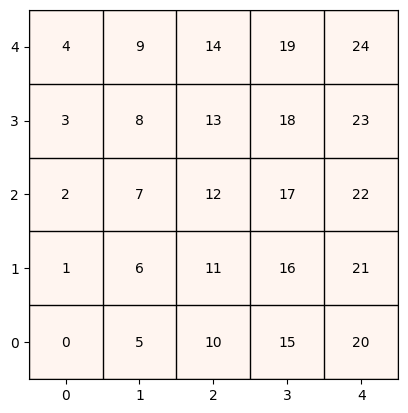

In [4]:
gym_env = gym.make('EmptyGridworld-v1')
env = gym_env.unwrapped

env.image()

In [5]:
from gym_classics.algorithms.MC import sample_episode

sample_episode(env, max_len=10000)

[(0, 1, -1, 5),
 (5, 3, -1, 0),
 (0, 3, -1, 0),
 (0, 2, -1, 0),
 (0, 0, -1, 1),
 (1, 2, -1, 0),
 (0, 1, -1, 5),
 (5, 2, -1, 5),
 (5, 2, -1, 5),
 (5, 3, -1, 0),
 (0, 1, -1, 5),
 (5, 2, -1, 5),
 (5, 0, -1, 6),
 (6, 2, -1, 5),
 (5, 2, -1, 5),
 (5, 2, -1, 5),
 (5, 3, -1, 0),
 (0, 0, -1, 1),
 (1, 1, -1, 6),
 (6, 2, -1, 5),
 (5, 3, -1, 0),
 (0, 2, -1, 0),
 (0, 1, -1, 5),
 (5, 1, -1, 10),
 (10, 0, -1, 11),
 (11, 1, -1, 16),
 (16, 2, -1, 15),
 (15, 3, -1, 10),
 (10, 3, -1, 5),
 (5, 2, -1, 5),
 (5, 3, -1, 0),
 (0, 3, -1, 0),
 (0, 3, -1, 0),
 (0, 2, -1, 0),
 (0, 1, -1, 5),
 (5, 3, -1, 0),
 (0, 2, -1, 0),
 (0, 1, -1, 5),
 (5, 0, -1, 6),
 (6, 1, -1, 11),
 (11, 0, -1, 12),
 (12, 3, -1, 7),
 (7, 0, -1, 8),
 (8, 2, -1, 7),
 (7, 3, -1, 2),
 (2, 1, -1, 7),
 (7, 3, -1, 2),
 (2, 3, -1, 2),
 (2, 3, -1, 2),
 (2, 1, -1, 7),
 (7, 1, -1, 12),
 (12, 2, -1, 11),
 (11, 3, -1, 6),
 (6, 3, -1, 1),
 (1, 0, -1, 2),
 (2, 2, -1, 1),
 (1, 3, -1, 1),
 (1, 0, -1, 2),
 (2, 0, -1, 3),
 (3, 2, -1, 2),
 (2, 3, -1, 2),
 (2, 3

## State Features

We use here simply the x and y-coordinates as the state feature vector $\mathbf{x}(s)$. We also add an intercept (a 1) to the beginning.

In [6]:
coordinates = [env.decode(s) for s in range(env.observation_space.n)]
state_features = [np.concatenate([np.array([1]), np.array(coord)]) for coord in coordinates]

state_features

[array([1, 0, 0]),
 array([1, 0, 1]),
 array([1, 0, 2]),
 array([1, 0, 3]),
 array([1, 0, 4]),
 array([1, 1, 0]),
 array([1, 1, 1]),
 array([1, 1, 2]),
 array([1, 1, 3]),
 array([1, 1, 4]),
 array([1, 2, 0]),
 array([1, 2, 1]),
 array([1, 2, 2]),
 array([1, 2, 3]),
 array([1, 2, 4]),
 array([1, 3, 0]),
 array([1, 3, 1]),
 array([1, 3, 2]),
 array([1, 3, 3]),
 array([1, 3, 4]),
 array([1, 4, 0]),
 array([1, 4, 1]),
 array([1, 4, 2]),
 array([1, 4, 3]),
 array([1, 4, 4])]

We use the linear approximation $\hat{v}(s,\mathbf{w}) = \mathbf{w}^\top \mathbf{x}(s)$, 
where $\mathbf{w}$ is the parameter vector we want to learn.

In [7]:
def v_hat(s, w):
    x_s = state_features[s]
    return np.dot(w, x_s)

I manually define here a weight vector.

In [8]:
w = np.array([10, 10, 10])

print (f" v_hat((0,0), w) = {v_hat(env.encode((0,0)), w)}")
print (f" v_hat((4,4), w) = {v_hat(env.encode((4,4)), w)}")

 v_hat((0,0), w) = 10
 v_hat((4,4), w) = 90


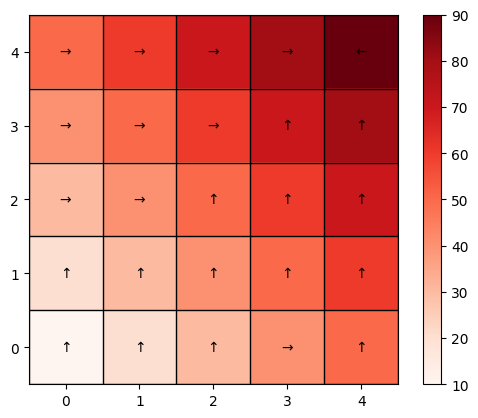

In [9]:
from gym_classics.algorithms.policy import greedy_policy

V = np.array([v_hat(s, w) for s in range(env.observation_space.n)])

pol = greedy_policy(env, V)

env.image(V, policy=pol)

## Learning w


We want to minimize the mean square value error: $\overline{VE} = \sum_{s\in \mathcal{S}} \mu(s) [v_\pi - \hat{v}(s, \mathbf{w})]^2$

This leads to:

* SGD update: $\mathbf{w}_{t+1} = \mathbf{w}_t + \alpha (U_t - \hat{v}(S_t, \mathbf{w}_t)) \mathbf{x}(S_t)$
* Gradient: $\nabla \hat{v}(s, \mathbf{w}) = \mathbf{x}(s)$


## Semi-Gradient TD(0) with Linear Function Approximation

![Semi-Gradient TD(0)](https://raw.githubusercontent.com/mhahsler/Introduction_to_Reinforcement_Learning/refs/heads/main/figures/RL-Intro_Alg_Semi_gradient_TD0.png)

In [10]:
def semi_gradient_TD0_estimation(env, policy, n, alpha, gamma, max_episode_length=100, verbose = True):
    assert alpha > 0 and alpha <= 1, "Alpha must be in (0,1]"
    assert gamma >= 0 and gamma <= 1, "Gamma must be in [0,1]"
    assert n > 0, "Number of episodes must be positive"
    assert max_episode_length > 0, "Max episode length must be positive"
    
    w = np.zeros(3)  # Initialize weights (intercept + x and y)

    for episode in range(n):
        state, _ = env.reset()
        done = False

        i = 0
        while not done and i < max_episode_length:
            action = policy[state]  # follow policy
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            
            # Semi-gradient TD(0) update
            # Note: v_hat(terminal, w) needs to be 0
            if terminated:
                w += alpha * (reward - v_hat(state, w)) * state_features[state]    
            else: 
                w += alpha * (reward + gamma * v_hat(next_state, w) - v_hat(state, w)) * state_features[state]
             
            if verbose:
                print (f"Episode {episode+1}, Step {i+1}: S={state}, A={action}, R={reward}, S'={next_state}, w={w}")

            state = next_state
            i += 1

    return w

In [11]:
w = semi_gradient_TD0_estimation(env, pol, n=1000, alpha=0.01, gamma=1, verbose=False)
w

array([92.98,  1.  ,  1.01])

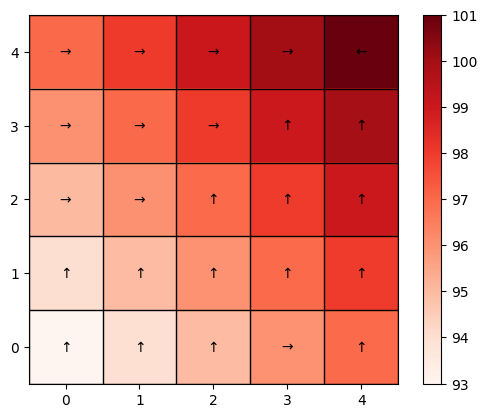

In [12]:
V = np.array([v_hat(s, w) for s in range(env.observation_space.n)])
env.image(V, policy=pol)

In [13]:
V.reshape(5,5)[::-1]

array([[ 96.98,  97.99,  98.99, 100.  , 101.01],
       [ 95.98,  96.99,  97.99,  99.  , 100.01],
       [ 94.98,  95.99,  97.  ,  98.  ,  99.01],
       [ 93.98,  94.99,  96.  ,  97.  ,  98.01],
       [ 92.98,  93.99,  95.  ,  96.  ,  97.01]])

# Semi-Gradient Sarsa

![Semi-Gradient Sarsa](https://raw.githubusercontent.com/mhahsler/Introduction_to_Reinforcement_Learning/refs/heads/main/figures/RL-Intro_Alg_Semi_gradient_SARSA.png)

To construct a linear state-action approximation function is a little more tricky. [Geramifard et al. (2013)](https://doi.org/10.1561/2200000042) suggest to use a state feature vectors to construct the complete state-action feature vector. It uses one shared intercept and then for each action a state feature component.
In our case we get a $w$ vectors of length 1 intercept + 4 actions $\times$ 2 coordinate values = 9. Here is the layout for the weight vector $\mathbf{w}$:

`[intercept, x_action0, y_action0, x_action1, y_action1, x_action2, y_action2, x_action3, y_action3]`

Only teh intercept and the weights belonging to the action are used.

In [24]:
# choose intercept at 0 and the action-specific weights so we end up with 3 active weights.
def active_weights(a):
    return [0, a * 2 + 1, a * 2 + 2]

active_weights(1)

[0, 3, 4]

In [ ]:
def q_hat(s, a, w): 
    w_action = w[active_weights(a)]
    return np.dot(w_action, state_features[s])

In [15]:
w = np.array([1,2,2,3,3,4,4,5,5])

# state 7 is (2,1): for action 2 this should be 1 (intercept) + 2*4+1*4 = 13
q_hat(7, 2, w)

np.int64(13)

In [25]:
def semi_gradient_Sarsa(env, n, epsilon, alpha, gamma, max_episode_length=100, verbose = True):
    assert alpha > 0 and alpha <= 1, "Alpha must be in (0,1]"
    assert gamma >= 0 and gamma <= 1, "Gamma must be in [0,1]"
    assert epsilon >=0 and epsilon <=1, "Epsilon must be in [0,1]"
    assert n > 0, "Number of episodes must be positive"
    assert max_episode_length > 0, "Max episode length must be positive"
    
    w = np.zeros(9)  # Initialize weights (intercept + action weights)
    
    # helper used later
    def epsilon_greedy_action(state, epsilon):
        if np.random.rand() < epsilon:
            return env.action_space.sample()
        else:
            q_values = [q_hat(state, a, w) for a in range(env.action_space.n)]
            return np.argmax(q_values)
    
    for episode in range(n):
        state, _ = env.reset()
        action = epsilon_greedy_action(state, epsilon)
        done = False

        i = 0
        while not done and i < max_episode_length:
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            
            if terminated:
                next_action = None
                w[active_weights(action)] += alpha * (reward - q_hat(state, action, w)) * state_features[state]
                
            else:
                next_action = epsilon_greedy_action(next_state, epsilon)
                w[active_weights(action)] += alpha * (reward + gamma * q_hat(next_state, next_action, w) - q_hat(state, action, w)) * state_features[state]
             
            if verbose:
                print (f"Episode {episode+1}, Step {i+1}: S={state}, A={action}, R={reward}, S'={next_state}, w={w}")

            state = next_state
            action = next_action
            i += 1

    return w  
    

In [26]:
semi_gradient_Sarsa(env, n=10, epsilon=0.1, alpha=0.01, gamma=1, verbose=True)

Episode 1, Step 1: S=0, A=3, R=-1, S'=0, w=[-0.01  0.    0.    0.    0.    0.    0.    0.    0.  ]
Episode 1, Step 2: S=0, A=0, R=-1, S'=1, w=[-0.02  0.    0.    0.    0.    0.    0.    0.    0.  ]
Episode 1, Step 3: S=1, A=0, R=-1, S'=2, w=[-0.03  0.   -0.01  0.    0.    0.    0.    0.    0.  ]
Episode 1, Step 4: S=2, A=3, R=-1, S'=2, w=[-0.04  0.   -0.01  0.    0.    0.    0.    0.   -0.02]
Episode 1, Step 5: S=2, A=1, R=-1, S'=7, w=[-0.05  0.   -0.01  0.   -0.02  0.    0.    0.   -0.02]
Episode 1, Step 6: S=7, A=1, R=-1, S'=12, w=[-0.06  0.   -0.01 -0.01 -0.04  0.    0.    0.   -0.02]
Episode 1, Step 7: S=12, A=2, R=-1, S'=11, w=[-0.07  0.   -0.01 -0.01 -0.04 -0.02 -0.02  0.   -0.02]
Episode 1, Step 8: S=11, A=2, R=-1, S'=10, w=[-0.08  0.   -0.01 -0.01 -0.04 -0.04 -0.03  0.   -0.02]
Episode 1, Step 9: S=10, A=0, R=-1, S'=11, w=[-0.09 -0.02 -0.01 -0.01 -0.04 -0.04 -0.03  0.   -0.02]
Episode 1, Step 10: S=11, A=0, R=-1, S'=12, w=[-0.1  -0.04 -0.02 -0.01 -0.04 -0.04 -0.03  0.   -0.02]


array([-10.04,  -0.67,  -1.05,  -0.68,  -1.02,  -0.69,  -0.99,  -0.67,
        -1.05])


&copy; 2025 [Michael Hahsler](http://michael.hahsler.net). 
This work is openly licensed under [Creative Commons Attribution-ShareAlike 4.0 International (CC BY-SA 4.0) License](https://creativecommons.org/licenses/by-sa/4.0/)

![CC BY-SA 4.0](https://licensebuttons.net/l/by-sa/3.0/88x31.png)